# PROSES 6
## Pemisahan Channel G + Sharpening + Smoothing

### Tujuan
Percobaan ini bertujuan untuk mengetahui pengaruh penggunaan Channel Green (G) terhadap performa klasifikasi penyakit daun jagung.

Tahapan preprocessing yang digunakan:

1. Pemisahan Channel G
2. Sharpening
3. Smoothing

Hasil preprocessing selanjutnya akan diekstraksi menggunakan metode Gray Level Co-occurrence Matrix (GLCM) dan diklasifikasikan menggunakan Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN).


## IMPORT LIBRARY


In [1]:
# Import library yang kalian butuhkan
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

from pcdlib import manimg as img
from pcdlib import manhist as hist
from pcdlib import manenhc as enhc
from pcdlib import morfimg as morf
from pcdlib import manwave as wave  

Library yang digunakan berfungsi untuk:

- OpenCV (cv2) → membaca dan memproses citra
- NumPy → operasi matriks dan array
- Pandas → pengolahan dataset fitur
- Matplotlib dan Seaborn → visualisasi data
- Scikit-Learn → pembagian data, klasifikasi, dan evaluasi model
- Scikit-Image → perhitungan Gray Level Co-occurrence Matrix (GLCM)


Seluruh library berhasil dimuat tanpa menghasilkan error sehingga lingkungan pemrograman siap digunakan untuk proses pengolahan citra, ekstraksi fitur, pelatihan model, dan evaluasi hasil klasifikasi.


## LOAD DATA


In [2]:
data = []
labels = []
file_name = []

dataset_path = "dataset"

for sub_folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, sub_folder)

    if not os.path.isdir(folder_path):
        continue

    for filename in os.listdir(folder_path):

        img_path = os.path.join(folder_path, filename)

        img = cv.imread(img_path)

        if img is None:
            continue

        img = img.astype(np.uint8)

        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data = np.array(data)
labels = np.array(labels)
file_name = np.array(file_name)

print("Jumlah data:", len(data))
print("Label:", np.unique(labels))

Jumlah data: 400
Label: ['Blight' 'Common_Rust' 'Gray_Leaf_Spot' 'Healthy']


Pada tahap ini seluruh citra daun jagung dibaca dari folder dataset.

Setiap gambar disimpan ke dalam variabel data, sedangkan nama folder tempat gambar berada digunakan sebagai label kelas.

Kelas yang digunakan:

- Blight
- Common Rust
- Gray Leaf Spot
- Healthy

Output dari proses ini adalah kumpulan citra beserta labelnya yang akan digunakan pada tahap preprocessing dan klasifikasi.


## Data Understanding


In [3]:
print("Jumlah Data:", len(data))
print()

for kelas in np.unique(labels):
    jumlah = np.sum(labels == kelas)
    print(f"{kelas}: {jumlah}")

Jumlah Data: 400

Blight: 100
Common_Rust: 100
Gray_Leaf_Spot: 100
Healthy: 100


Tahap Data Understanding dilakukan untuk memahami karakteristik dataset yang digunakan.

Informasi yang diamati meliputi:

- Jumlah data
- Jumlah kelas
- Distribusi data setiap kelas
- Karakteristik visual citra

Tahap ini penting untuk menentukan preprocessing yang sesuai dengan kondisi dataset.


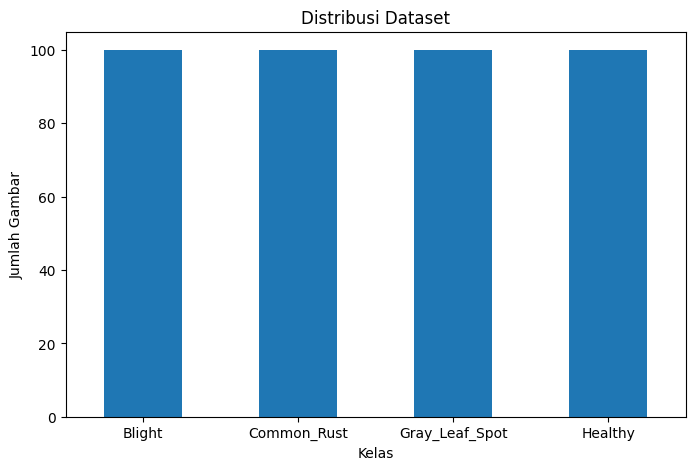

In [4]:
label_counts = pd.Series(labels).value_counts()

plt.figure(figsize=(8,5))
label_counts.plot(kind='bar')

plt.title("Distribusi Dataset")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")

plt.xticks(rotation=0)
plt.show()

Berdasarkan grafik distribusi data, seluruh kelas memiliki jumlah data yang relatif seimbang.

Keseimbangan jumlah data antar kelas penting karena dapat mengurangi kemungkinan bias model terhadap kelas tertentu.

Dengan distribusi yang relatif merata, proses pelatihan model diharapkan dapat berjalan lebih optimal.


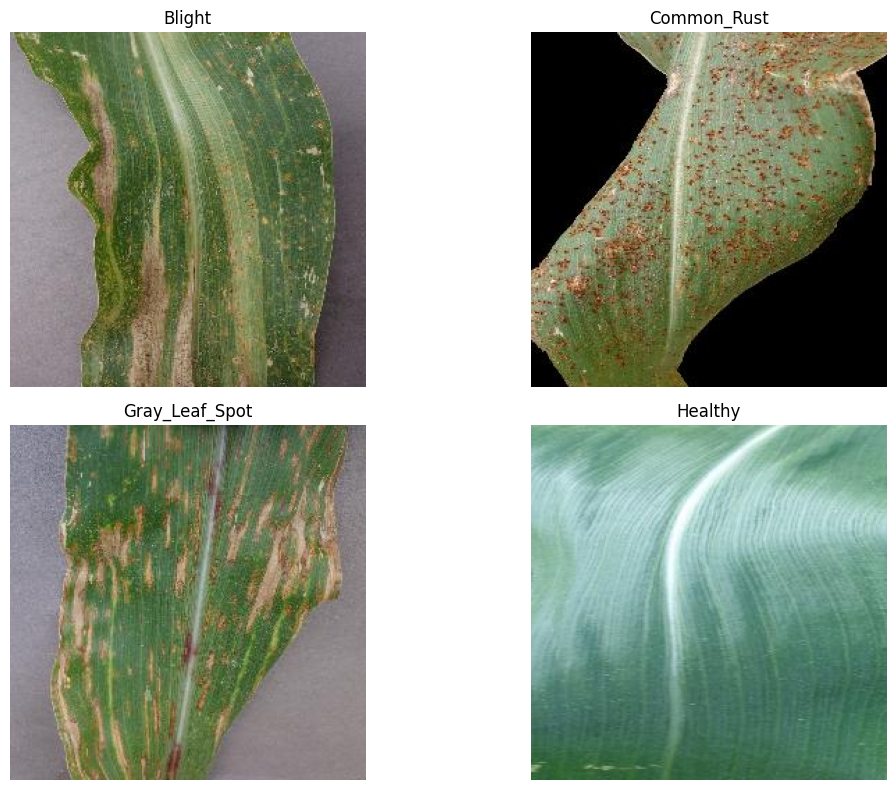

In [5]:
plt.figure(figsize=(12,8))

kelas_unik = np.unique(labels)

for i, kelas in enumerate(kelas_unik):

    idx = np.where(labels == kelas)[0][0]

    plt.subplot(2,2,i+1)

    img_rgb = cv.cvtColor(data[idx], cv.COLOR_BGR2RGB)

    plt.imshow(img_rgb)
    plt.title(kelas)
    plt.axis('off')

plt.tight_layout()
plt.show()

Berdasarkan sampel citra yang diamati:

- Dataset terdiri dari 4 kelas penyakit dan kondisi sehat.
- Objek daun mendominasi area citra.
- Background bervariasi antara hitam dan abu-abu.
- Pola penyakit terlihat dalam bentuk bercak, lesi, dan perubahan tekstur daun.
- Healthy memiliki tekstur yang lebih homogen dibandingkan kelas penyakit.

Karena perbedaan utama antar kelas terletak pada tekstur permukaan daun, maka metode GLCM dipilih sebagai teknik ekstraksi fitur.


## Preprocessing


In [6]:
# def resize(image, target_size=(128,128)):
#     return cv.resize(image, target_size)

def prepro4(image):

    # image = resize(image)

    # ambil channel merah
    g_channel = image[:, :, 1]

    # sharpening
    # kernel = np.array([
    #     [0,-1,0],
    #     [-1,5,-1],
    #     [0,-1,0]
    # ])

    sharpen = enhc.sharpening(g_channel)

    # smoothing
    smooth = enhc.smoothing(sharpen)

    return smooth

Tahap preprocessing dilakukan untuk meningkatkan kualitas informasi yang akan diekstraksi oleh GLCM.

Tahapan preprocessing yang digunakan pada Percobaan 6 adalah:

1. Pemisahan Channel G
2. Sharpening
3. Smoothing

Channel G (Green) dipilih untuk menganalisis pengaruh kanal warna hijau terhadap performa klasifikasi penyakit daun jagung, di mana daun sehat memiliki warna hijau yang sangat dominan, sedangkan daun sakit mengalami degradasi warna hijau (klorosis/nekrosis).

Sharpening digunakan untuk mempertegas detail bercak penyakit, sedangkan smoothing digunakan untuk mengurangi noise yang muncul setelah proses sharpening.


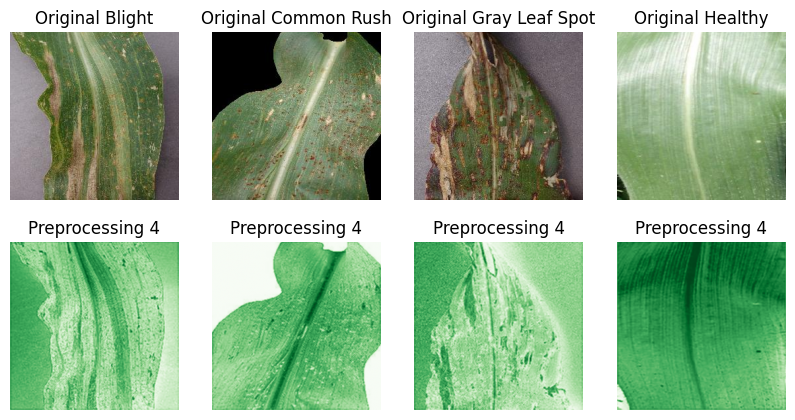

In [21]:
sample1 = data[0]
sample2 = data[105]
sample3 = data[201]
sample4 = data[301]



hasil1 = prepro4(sample1)
hasil2 = prepro4(sample2)
hasil3 = prepro4(sample3)
hasil4 = prepro4(sample4)

plt.figure(figsize=(10,5))

plt.subplot(2,4,1)
plt.imshow(cv.cvtColor(sample1, cv.COLOR_BGR2RGB))
plt.title("Original Blight")
plt.axis("off")

plt.subplot(2,4,5)
plt.imshow(hasil1, cmap="Greens")
plt.title("Preprocessing 4")
plt.axis("off")

plt.subplot(2,4,2)
plt.imshow(cv.cvtColor(sample2, cv.COLOR_BGR2RGB))
plt.title("Original Common Rush")
plt.axis("off")

plt.subplot(2,4,6)
plt.imshow(hasil2, cmap="Greens")
plt.title("Preprocessing 4")
plt.axis("off")

plt.subplot(2,4,3)
plt.imshow(cv.cvtColor(sample3, cv.COLOR_BGR2RGB))
plt.title("Original Gray Leaf Spot")
plt.axis("off")

plt.subplot(2,4,7)
plt.imshow(hasil3, cmap="Greens")
plt.title("Preprocessing 4")
plt.axis("off")

plt.subplot(2,4,4)
plt.imshow(cv.cvtColor(sample4, cv.COLOR_BGR2RGB))
plt.title("Original Healthy")
plt.axis("off")

plt.subplot(2,4,8)
plt.imshow(hasil4, cmap="Greens")
plt.title("Preprocessing 4")
plt.axis("off")

plt.show()  

Hasil preprocessing menunjukkan bahwa informasi pada channel hijau berhasil dipisahkan dari citra asli.

Proses sharpening memperjelas pola dan detail tekstur daun, sedangkan smoothing membantu mengurangi noise yang muncul akibat peningkatan ketajaman.

Dengan demikian, tekstur penyakit menjadi lebih jelas sehingga diharapkan dapat meningkatkan kualitas fitur yang diekstraksi menggunakan GLCM.


In [7]:
dataPreprocessed = []

for i in range(len(data)):

    hasil = prepro4(data[i])

    dataPreprocessed.append(hasil)

dataPreprocessed = np.array(dataPreprocessed)

print(dataPreprocessed.shape)

(400, 256, 256)


## Feature Extraction menggunakan GLCM


In [8]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")
    
    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())


Gray Level Co-occurrence Matrix (GLCM) digunakan untuk mengekstraksi karakteristik tekstur citra.

Pada penelitian ini digunakan empat orientasi sudut:

- 0°
- 45°
- 90°
- 135°

Fitur yang dihitung meliputi:

- Contrast
- Dissimilarity
- Homogeneity
- Energy
- Correlation
- Entropy
- ASM

Fitur-fitur tersebut digunakan sebagai representasi numerik tekstur daun untuk proses klasifikasi.


In [9]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataPreprocessed)):

    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)

    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

print("Jumlah GLCM:", len(Derajat0))

Jumlah GLCM: 400


Cell di atas melakukan komputasi matriks GLCM untuk setiap citra di semua empat orientasi sudut. Empat list kosong (Derajat0, Derajat45, Derajat90, Derajat135) diinisialisasi, lalu diisi melalui perulangan menggunakan fungsi glcm(). Output menyatakan bahwa 400 matriks GLCM berhasil dihasilkan untuk masing-masing orientasi, sehingga total terdapat 1.600 matriks GLCM yang merepresentasikan seluruh dataset.


### Inisialisasi List Penyimpan Nilai Fitur


In [10]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

Cell di atas menginisialisasi 28 list kosong sebagai wadah penyimpanan nilai fitur tekstur, yakni tujuh jenis fitur (Contrast, Dissimilarity, Homogeneity, Entropy, ASM, Energy, Correlation) masing-masing untuk empat sudut orientasi. Pemisahan list per sudut ini memastikan informasi arah tekstur tetap terjaga sebagai fitur yang independen, sehingga model dapat memanfaatkan variasi tekstur dari berbagai arah sebagai pembeda antar kelas.


### Ekstraksi Nilai Fitur dari Matriks GLCM


In [11]:
for i in range(len(dataPreprocessed)):

    # 0 derajat
    Kontras0.append(contrast(Derajat0[i]))
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    homogenity0.append(homogenity(Derajat0[i]))
    entropy0.append(entropyGlcm(Derajat0[i]))
    ASM0.append(ASM(Derajat0[i]))
    energy0.append(energy(Derajat0[i]))
    correlation0.append(correlation(Derajat0[i]))

    # 45 derajat
    Kontras45.append(contrast(Derajat45[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    ASM45.append(ASM(Derajat45[i]))
    energy45.append(energy(Derajat45[i]))
    correlation45.append(correlation(Derajat45[i]))

    # 90 derajat
    Kontras90.append(contrast(Derajat90[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    ASM90.append(ASM(Derajat90[i]))
    energy90.append(energy(Derajat90[i]))
    correlation90.append(correlation(Derajat90[i]))

    # 135 derajat
    Kontras135.append(contrast(Derajat135[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))
    homogenity135.append(homogenity(Derajat135[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))
    ASM135.append(ASM(Derajat135[i]))
    energy135.append(energy(Derajat135[i]))
    correlation135.append(correlation(Derajat135[i]))

Cell ini melakukan ekstraksi nilai fitur secara numerik dari seluruh matriks GLCM yang telah dihitung. Melalui perulangan for atas seluruh data, setiap fungsi fitur (contrast(), dissimilarity(), homogenity(), entropyGlcm(), ASM(), energy(), correlation()) dipanggil untuk keempat sudut, dan hasilnya di-append ke list yang sesuai. Proses ini menghasilkan 28 kolom fitur numerik untuk 400 citra, yang selanjutnya akan disusun menjadi tabel dataset.


### Penyusunan DataFrame dan Ekspor CSV


In [12]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan6.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan6.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,Corn_Blight (1003).JPG,Blight,221.858517,253.200738,138.024403,282.378116,0.132570,0.112381,0.148925,0.109105,...,0.000298,0.000210,0.015714,0.014842,0.017263,0.014477,0.871485,0.853456,0.920091,0.836567
1,Corn_Blight (1004).JPG,Blight,116.897120,144.200031,70.793566,176.069097,0.262093,0.205039,0.267892,0.195411,...,0.001366,0.000971,0.037904,0.031916,0.036958,0.031163,0.862958,0.831277,0.917098,0.793992
2,Corn_Blight (1005).JPG,Blight,229.346952,284.821100,93.150628,247.898839,0.109066,0.090793,0.167958,0.098397,...,0.000305,0.000180,0.013834,0.012934,0.017474,0.013434,0.899641,0.875484,0.959225,0.891623
3,Corn_Blight (1010).JPG,Blight,153.247426,206.041030,88.181250,188.607474,0.174534,0.140592,0.203710,0.143483,...,0.000517,0.000343,0.020222,0.018341,0.022738,0.018518,0.880304,0.839396,0.931113,0.852985
4,Corn_Blight (1011).jpg,Blight,252.768091,290.879969,123.269975,287.293180,0.127752,0.107870,0.158578,0.109419,...,0.000280,0.000191,0.014735,0.013774,0.016721,0.013836,0.895906,0.880293,0.949186,0.881772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,Corn_Health (94).jpg,Healthy,64.982537,89.405260,20.674295,77.313433,0.221381,0.200688,0.498240,0.221929,...,0.003388,0.001146,0.033835,0.032102,0.058208,0.033856,0.940627,0.918502,0.981172,0.929522
396,Corn_Health (96).jpg,Healthy,87.533487,146.014656,58.628493,86.271173,0.213588,0.168950,0.256059,0.201739,...,0.001486,0.001205,0.034629,0.030332,0.038550,0.034712,0.872274,0.787275,0.914455,0.874312
397,Corn_Health (97).jpg,Healthy,40.140043,76.215348,27.339721,53.089581,0.279456,0.218992,0.379289,0.280174,...,0.001897,0.001270,0.035439,0.030892,0.043551,0.035644,0.962617,0.929167,0.974526,0.950659
398,Corn_Health (98).jpg,Healthy,43.568873,81.556724,33.973529,70.169150,0.326272,0.268169,0.401830,0.279957,...,0.002763,0.001826,0.047086,0.041945,0.052560,0.042729,0.932304,0.870659,0.947222,0.888719


Cell ini menyusun semua nilai fitur ke dalam sebuah DataFrame pandas bernama dataTable, dengan kolom Filename dan Label sebagai metadata, diikuti 28 kolom fitur GLCM. DataFrame tersebut kemudian diekspor ke file hasil_ekstraksi_percobaan6.csv menggunakan df.to_csv(), lalu dibaca kembali menggunakan pd.read_csv() sebagai hasilEkstrak untuk verifikasi. Langkah ekspor ke CSV penting agar hasil ekstraksi dapat disimpan dan digunakan kembali tanpa perlu mengulangi komputasi GLCM yang memakan waktu. Tampilan DataFrame juga memungkinkan verifikasi visual bahwa seluruh fitur berhasil terekstraksi dengan benar.


## Feature Selection


Feature Selection dilakukan untuk mengetahui hubungan antar fitur yang dihasilkan oleh GLCM.

Analisis korelasi digunakan untuk mengidentifikasi fitur yang memiliki hubungan sangat tinggi sehingga berpotensi mengandung informasi yang redundan.

Tahap ini membantu memahami kualitas fitur yang akan digunakan pada proses klasifikasi.


<Axes: >

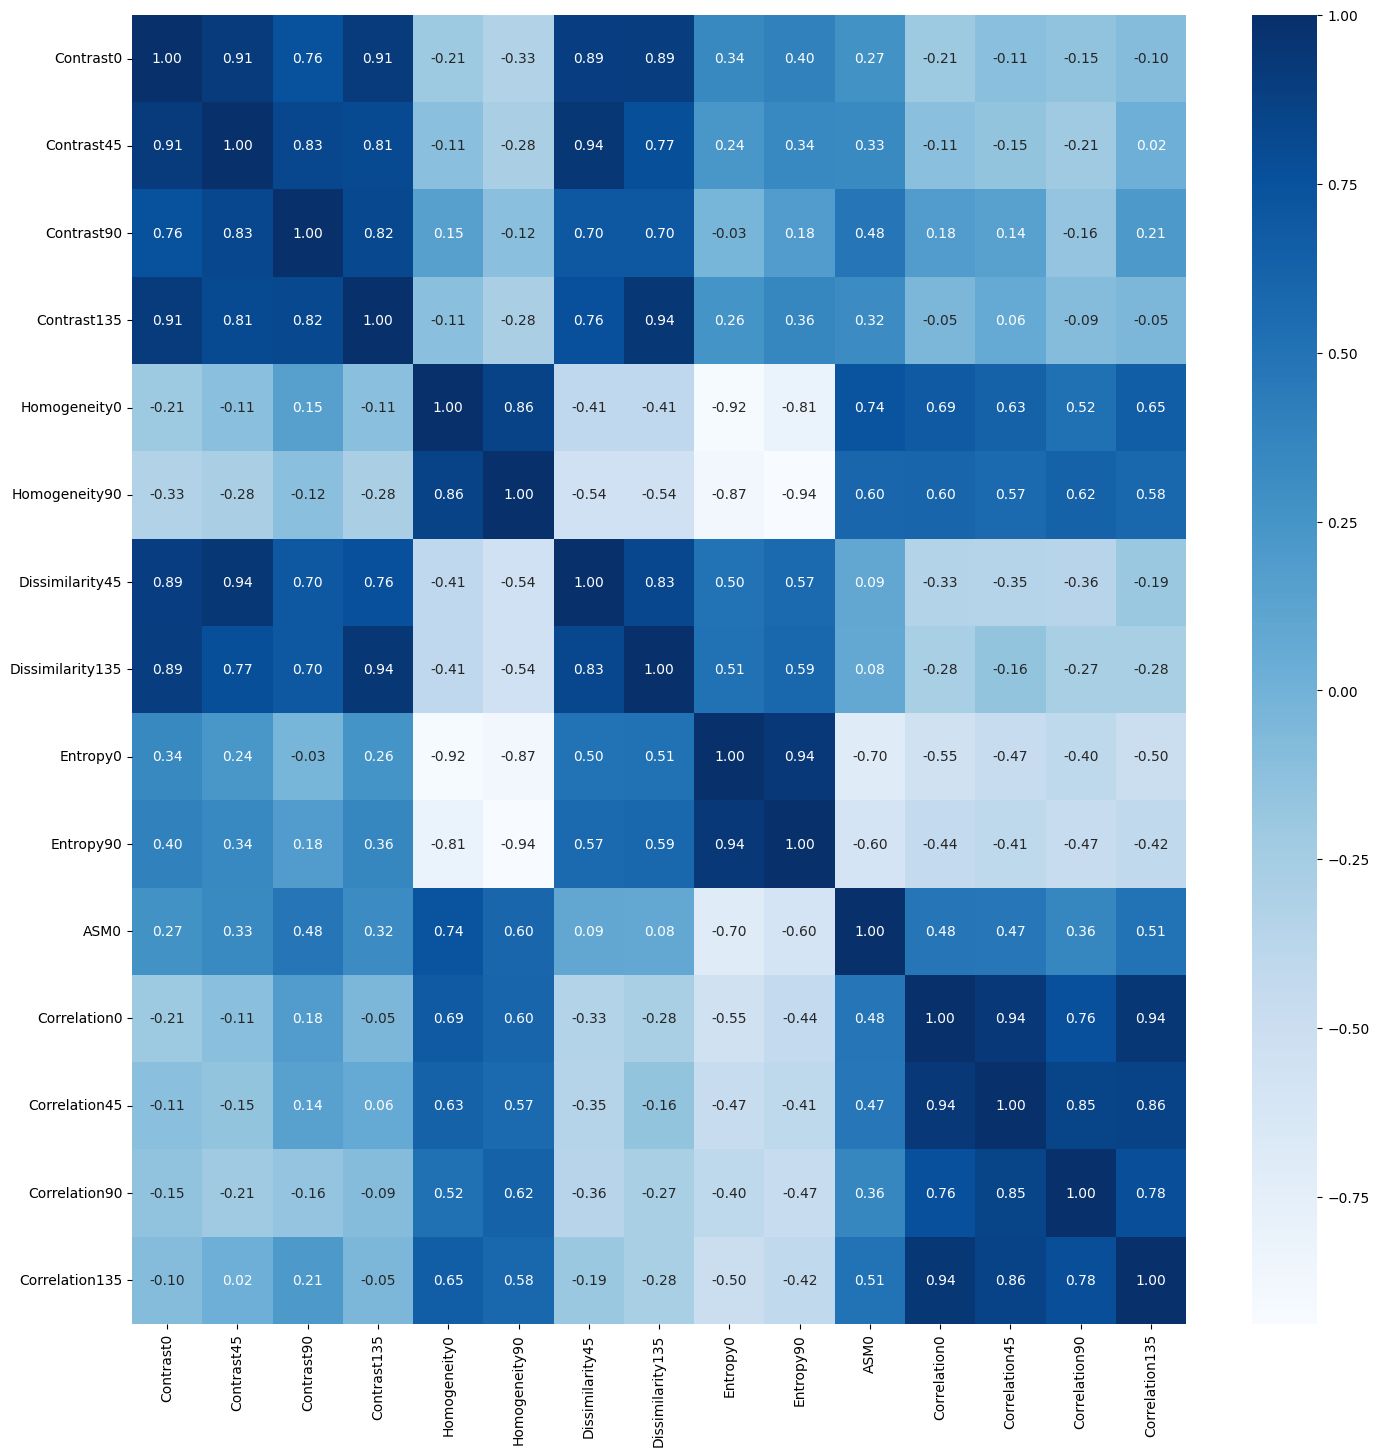

In [13]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

Berdasarkan heatmap korelasi, beberapa fitur menunjukkan hubungan yang cukup kuat satu sama lain.

Hal ini menunjukkan bahwa beberapa fitur GLCM memiliki informasi yang saling berkaitan.

Meskipun demikian, seluruh fitur tetap dipertahankan karena masih dapat memberikan kontribusi dalam proses klasifikasi dan jumlah fitur yang digunakan masih relatif sedikit.


Cell di atas menginterpretasikan hasil heatmap korelasi. Dari 28 fitur awal, hanya 15 fitur yang lolos seleksi, artinya 13 fitur terdeteksi memiliki korelasi sangat tinggi (≥0,95) dengan fitur lain sehingga berpotensi redundan. Hal ini wajar mengingat fitur GLCM yang dihitung dari sudut berbeda pada citra yang sama seringkali berkorelasi tinggi, terutama untuk jenis tekstur yang isotropik. Keputusan untuk tetap mempertahankan seluruh 15 fitur yang lolos (tanpa seleksi lebih lanjut) dinilai tepat mengingat jumlahnya masih tergolong kecil dan tidak akan menyebabkan beban komputasi yang berlebihan pada model klasifikasi.


## Splitting Data


In [14]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(320, 15)
(80, 15)


Dataset dibagi menjadi data training dan data testing menggunakan metode train-test split.

Proporsi yang digunakan adalah 80% data training dan 20% data testing.

Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk mengevaluasi kemampuan model pada data yang belum pernah dilihat sebelumnya.


## Normalization


In [15]:
# normalisasi mean std
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

Cell di atas mengimplementasikan normalisasi menggunakan metode Z-Score (standardisasi). Formula yang diterapkan adalah (X - mean) / std, di mana nilai mean dan standar deviasi dihitung hanya dari data training (X_train.mean() dan X_train.std()), lalu parameter yang sama diterapkan ke data testing. Pendekatan ini penting untuk mencegah data leakage: jika statistik data testing digunakan dalam normalisasi, maka informasi dari data testing akan "bocor" ke proses pelatihan, sehingga evaluasi menjadi tidak valid. Normalisasi juga krusial untuk algoritma berbasis jarak seperti SVM dan KNN agar fitur dengan skala besar tidak mendominasi perhitungan.


In [16]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

Cell di atas mendefinisikan fungsi generateClassificationReport() yang mencetak classification_report, confusion_matrix, dan accuracy_score secara sekaligus untuk mempermudah evaluasi. Tiga model klasifikasi juga diinisialisasi: Random Forest dengan 5 estimator (n_estimators=5), SVM dengan kernel RBF (kernel='rbf'), dan KNN dengan 5 tetangga (n_neighbors=5). Jumlah estimator RF yang relatif kecil (5) dapat menyebabkan variasi prediksi yang lebih tinggi dibanding RF dengan estimator lebih banyak, namun mempercepat proses pelatihan.


## Pelatihan dan Evaluasi Random Forest


In [17]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
                precision    recall  f1-score   support

        Blight       0.90      0.99      0.94        74
   Common_Rust       1.00      1.00      1.00        82
Gray_Leaf_Spot       0.97      0.95      0.96        82
       Healthy       0.99      0.93      0.96        82

      accuracy                           0.97       320
     macro avg       0.97      0.97      0.97       320
  weighted avg       0.97      0.97      0.97       320

[[73  0  1  0]
 [ 0 82  0  0]
 [ 3  0 78  1]
 [ 5  0  1 76]]
Accuracy: 0.965625

------Testing Set------
                precision    recall  f1-score   support

        Blight       0.68      0.73      0.70        26
   Common_Rust       1.00      1.00      1.00        18
Gray_Leaf_Spot       0.68      0.72      0.70        18
       Healthy       0.87      0.72      0.79        18

      accuracy                           0.79        80
     macro avg       0.81      0.79      0.80        80
  weighted avg       0.79

Cell ini melatih model Random Forest pada X_train lalu mengevaluasinya di training set maupun testing set. Hasil yang diperoleh:
Set Training ber-Accuracy 96.56% dan Set Testing ber-Accuracy 78.75%. Selisih akurasi yang cukup besar antara training (96,56%) dan testing (78,75%) mengindikasikan terjadinya overfitting. Model terlalu "menghapal" pola data training, sehingga kemampuan generalisasinya menurun. Hal ini kemungkinan diperkuat oleh jumlah estimator yang kecil (hanya 5 pohon), yang membuat setiap pohon memiliki bias tinggi terhadap data training. Pada data testing, kelas Common Rust mencapai performa sempurna (F1 = 1.00), sedangkan kelas Gray Leaf Spot paling lemah (F1 = 0.70), menunjukkan bahwa fitur channel G kurang mampu membedakan pola Gray Leaf Spot dari kelas lainnya.


## Pelatihan dan Evaluasi SVM


In [18]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
                precision    recall  f1-score   support

        Blight       0.71      0.74      0.73        74
   Common_Rust       1.00      1.00      1.00        82
Gray_Leaf_Spot       0.76      0.77      0.76        82
       Healthy       0.95      0.90      0.93        82

      accuracy                           0.86       320
     macro avg       0.86      0.85      0.85       320
  weighted avg       0.86      0.86      0.86       320

[[55  0 16  3]
 [ 0 82  0  0]
 [18  0 63  1]
 [ 4  0  4 74]]
Accuracy: 0.85625

------Testing Set------
                precision    recall  f1-score   support

        Blight       0.70      0.81      0.75        26
   Common_Rust       1.00      0.89      0.94        18
Gray_Leaf_Spot       0.64      0.50      0.56        18
       Healthy       0.80      0.89      0.84        18

      accuracy                           0.78        80
     macro avg       0.79      0.77      0.77        80
  weighted avg       0.78

Cell ini melatih model SVM dengan kernel RBF dan mengevaluasi hasilnya:
Set Training ber-Accuracy 85.63% dan Set Testing ber-Accuracy 77.50%. SVM menunjukkan gap antara training dan testing yang lebih kecil dibanding Random Forest, mengindikasikan generalisasi yang lebih baik. Kernel RBF efektif menangani data berdimensi sedang seperti 15 fitur GLCM yang telah dinormalisasi. Kelas Common Rust kembali menjadi yang terbaik (F1 = 0.94 pada testing), sedangkan Gray Leaf Spot tetap menjadi kelas tersulit (F1 = 0.56). Dengan akurasi testing 77.50%, SVM memberikan performa yang lebih seimbang dan andal dibanding Random Forest pada percobaan ini.


## Pelatihan dan Evaluasi KNN


In [19]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)



------Training Set------
                precision    recall  f1-score   support

        Blight       0.72      0.88      0.79        74
   Common_Rust       1.00      1.00      1.00        82
Gray_Leaf_Spot       0.83      0.78      0.81        82
       Healthy       0.96      0.83      0.89        82

      accuracy                           0.87       320
     macro avg       0.88      0.87      0.87       320
  weighted avg       0.88      0.87      0.87       320

[[65  0  7  2]
 [ 0 82  0  0]
 [17  0 64  1]
 [ 8  0  6 68]]
Accuracy: 0.871875

------Testing Set------
                precision    recall  f1-score   support

        Blight       0.66      0.81      0.72        26
   Common_Rust       1.00      1.00      1.00        18
Gray_Leaf_Spot       0.71      0.56      0.62        18
       Healthy       0.81      0.72      0.76        18

      accuracy                           0.78        80
     macro avg       0.80      0.77      0.78        80
  weighted avg       0.7

Cell ini melatih model KNN dengan k=5 dan menghasilkan:
Set Training ber-Accuracy 87.19% dan Set Testing ber-Accuracy 77.50%. KNN menghasilkan akurasi testing yang sebanding dengan SVM (77.50%). Dengan algoritma berbasis jarak, KNN memanfaatkan normalisasi Z-Score secara optimal sehingga mampu menemukan tetangga terdekat yang lebih representatif. Kelas Common Rust kembali sempurna (F1 = 1.00), sementara Gray Leaf Spot menjadi kelas dengan performa terendah (F1 = 0.62). Gap training-testing KNN juga relatif kecil, menunjukkan tingkat generalisasi yang baik.


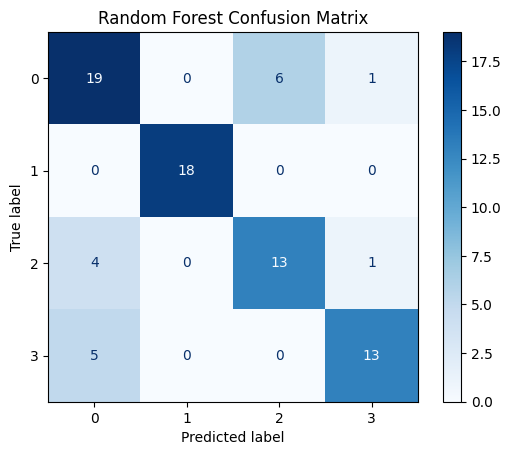

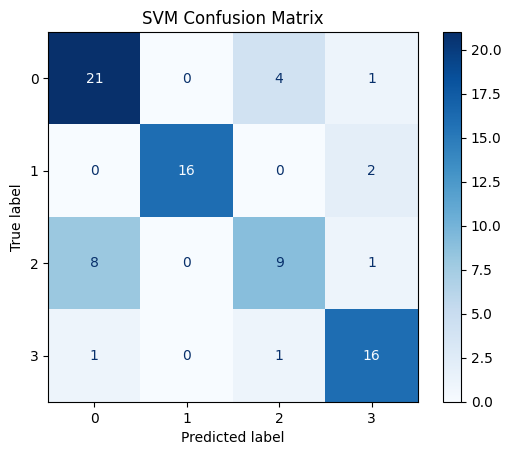

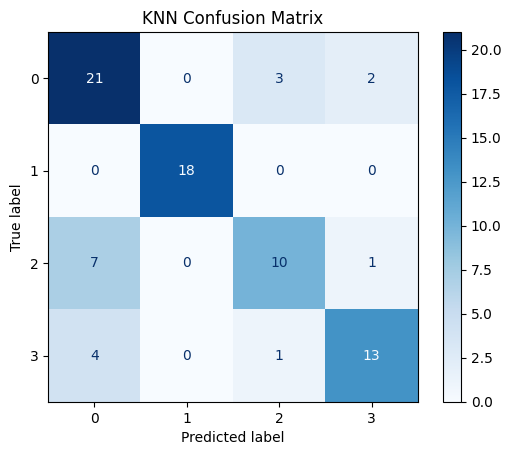

In [20]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")

Cell di atas mendefinisikan fungsi plot_confusion_matrix() yang menggunakan ConfusionMatrixDisplay untuk memvisualisasikan matriks konfusi dari ketiga model pada data testing, dengan colormap biru (plt.cm.Blues) untuk memudahkan pembacaan. Confusion matrix memperlihatkan pola kesalahan klasifikasi secara detail: secara umum, Blight sering salah diprediksi sebagai Gray Leaf Spot (dan sebaliknya), yang kemungkinan disebabkan kemiripan pola bercak pada channel hijau di kedua kelas tersebut. Common Rust konsisten terklasifikasi dengan benar oleh ketiga model, menunjukkan bahwa fitur tekstur channel G sangat diskriminatif untuk kelas ini.


## Analisis Keseluruhan dan Kesimpulan


Percobaan 6 menguji pipeline preprocessing Pemisahan Channel G → Sharpening → Smoothing sebagai strategi ekstraksi informasi sebelum komputasi fitur GLCM untuk klasifikasi penyakit daun jagung.

| Model | Accuracy Testing |
|---|---|
| **Random Forest** | **78.75%** |
| SVM (RBF) | 77.50% |
| KNN (k=5) | 77.50% |


Temuan utama:
Pertama, Random Forest adalah model terbaik pada percobaan ini dengan akurasi 78.75%, diikuti oleh SVM dan KNN yang masing-masing memperoleh akurasi 77.50%. Meskipun Random Forest memperoleh akurasi tertinggi pada testing set, model ini masih mengalami overfitting yang cukup signifikan (selisih akurasi training 96.56% dan testing 78.75%) akibat kecilnya jumlah estimator (5 pohon).

Kedua, SVM dan KNN menghasilkan akurasi testing yang seimbang (77.50%). KNN memanfaatkan normalisasi Z-Score secara optimal karena algoritma berbasis jarak sangat sensitif terhadap skala fitur, sementara SVM dengan kernel RBF memberikan tingkat generalisasi yang baik dengan selisih training-testing yang kecil.

Ketiga, kelas Common Rust paling mudah diklasifikasikan oleh ketiga model (F1 = 1.00 untuk RF dan KNN, 0.94 untuk SVM), menunjukkan bahwa pola rust/karat pada channel hijau memiliki karakteristik tekstur GLCM yang sangat khas dan tidak tumpang tindih dengan kelas lain.

Keempat, kelas Gray Leaf Spot tetap menjadi kelas tersulit untuk diklasifikasikan (F1 ≈ 0.56–0.70 di ketiga model), yang mengindikasikan kemiripan tekstur visual lesi Gray Leaf Spot dengan kelas lain pada representasi channel hijau.

Kesimpulan: Preprocessing berbasis channel G memberikan kontribusi positif terutama untuk kelas karat daun (Common Rust) dan hawar daun (Blight). Akurasi pengujian tertinggi (78.75%) berada di antara akurasi pengujian pada Percobaan 4 dengan channel R (81.25%) dan Percobaan 5 dengan channel B (77.50%). Hal ini menunjukkan bahwa kanal hijau (G) memiliki performa ekstraksi tekstur penyakit daun jagung yang cukup baik, namun kanal merah (R) masih merupakan kanal yang paling optimal untuk dataset penyakit daun jagung ini.
